<a href="https://colab.research.google.com/github/KDY-RiskManager/risk-management-portfolio/blob/main/05-sme-credit-scoring/sme_credit_scoring_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정 (지난 코풀라 프로젝트와 동일)
!apt-get -qq install fonts-nanum > /dev/null 2>&1
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# ============================================================
# [Cell 1] DART API 연결 + 전체 기업 고유번호 리스트 수집
# ============================================================
!pip install --quiet requests

import requests
import zipfile
import io
import xml.etree.ElementTree as ET
import pandas as pd
from getpass import getpass

# ------------------------------------------------------------
# API 키 입력 (화면에 노출되지 않는 방식으로 안전하게 입력)
# ------------------------------------------------------------
# getpass를 쓰면 입력한 키가 화면/로그에 남지 않음 (비밀번호 입력창처럼 동작)
DART_API_KEY = getpass("DART API 인증키를 입력하세요 (화면에 표시되지 않습니다): ")

# ------------------------------------------------------------
# 1) 전체 기업 고유번호 목록 다운로드 (corpCode.xml, zip 형태로 제공됨)
# ------------------------------------------------------------
url = "https://opendart.fss.or.kr/api/corpCode.xml"
params = {"crtfc_key": DART_API_KEY}

response = requests.get(url, params=params)
response.raise_for_status()  # 요청 실패 시(키 오류 등) 바로 에러를 띄워서 확인 가능하게 함

# 응답은 zip 파일이므로 압축을 풀어서 안의 XML을 읽음
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    xml_data = z.read(z.namelist()[0])

# XML 파싱: 기업별 corp_code, corp_name, stock_code, modify_date 추출
root = ET.fromstring(xml_data)
records = []
for child in root.findall('list'):
    records.append({
        'corp_code': child.findtext('corp_code'),
        'corp_name': child.findtext('corp_name'),
        'stock_code': child.findtext('stock_code'),  # 상장기업만 값이 있고, 비상장은 공백
        'modify_date': child.findtext('modify_date')
    })

corp_df = pd.DataFrame(records)
print(f"전체 기업 수: {len(corp_df):,}개")

# ------------------------------------------------------------
# 2) 상장기업만 필터링 (stock_code가 공백이 아닌 경우)
# ------------------------------------------------------------
corp_df['stock_code'] = corp_df['stock_code'].str.strip()
listed_df = corp_df[corp_df['stock_code'] != ''].reset_index(drop=True)
print(f"상장기업 수: {len(listed_df):,}개")

print("\n샘플 5개:")
print(listed_df.head())

전체 기업 수: 118,767개
상장기업 수: 3,988개

샘플 5개:
  corp_code corp_name stock_code modify_date
0  00260985      한빛네트     036720    20170630
1  00264529      엔플렉스     040130    20170630
2  00358545    동서정보기술     055000    20170630
3  00231567     애드모바일     032600    20170630
4  00359614       리더컴     056140    20170630


In [ ]:
# ============================================================
# [Cell 2 - 수정] 코스닥 상장법인 필터링 (DART 법인구분 API 활용, pykrx 불필요)
# ============================================================
from tqdm import tqdm
import time

# ------------------------------------------------------------
# DART 기업개황 API로 각 상장기업의 법인구분(코스피/코스닥/코넥스) 조회
# ------------------------------------------------------------
corp_cls_records = []
failed_count = 0

for _, row in tqdm(listed_df.iterrows(), total=len(listed_df), desc="법인구분 조회중"):
    try:
        url = "https://opendart.fss.or.kr/api/company.json"
        params = {"crtfc_key": DART_API_KEY, "corp_code": row['corp_code']}
        res = requests.get(url, params=params, timeout=5).json()
        if res.get('status') == '000':
            corp_cls_records.append({
                'corp_code': row['corp_code'],
                'corp_name': row['corp_name'],
                'stock_code': row['stock_code'],
                'corp_cls': res.get('corp_cls')  # Y=코스피, K=코스닥, N=코넥스, E=기타
            })
        time.sleep(0.05)
    except Exception:
        failed_count += 1
        continue

cls_df = pd.DataFrame(corp_cls_records)
print(f"조회 완료: {len(cls_df)}건 (실패: {failed_count}건)")
print("\n법인구분별 분포:")
print(cls_df['corp_cls'].value_counts())

# ------------------------------------------------------------
# 코스닥(K) 상장법인만 필터링
# ------------------------------------------------------------
kosdaq_df = cls_df[cls_df['corp_cls'] == 'K'].reset_index(drop=True)
print(f"\n코스닥 상장법인 수: {len(kosdaq_df)}개")
print(kosdaq_df.head())

법인구분 조회중: 100%|██████████| 3988/3988 [54:43<00:00,  1.21it/s]

조회 완료: 3988건 (실패: 0건)

법인구분별 분포:
corp_cls
K    1820
E    1227
Y     833
N     108
Name: count, dtype: int64

코스닥 상장법인 수: 1820개
  corp_code corp_name stock_code corp_cls
0  01170962       GRT     900290        K
1  01139266       로스웰     900260        K
2  01107665   크리스탈신소재     900250        K
3  00125938      삼보판지     023600        K
4  01068348        러셀     217500        K


In [5]:
# ============================================================
# [Cell 3] 재무제표 수집 (FY2023) + SME 필터링 + 감사의견 라벨(FY2024) 결합
# ============================================================
from tqdm import tqdm
import time

# ------------------------------------------------------------
# 계정명이 회사마다 조금씩 다르게 기재되는 경우가 있어
# 여러 후보 이름 중 하나라도 매칭되면 값을 가져오는 헬퍼 함수
# ------------------------------------------------------------
def find_account(items, candidates):
    for item in items:
        if item.get('account_nm') in candidates:
            try:
                return float(item.get('thstrm_amount', '0').replace(',', ''))
            except (ValueError, AttributeError):
                return None
    return None

# ------------------------------------------------------------
# 1차: FY2023 재무제표 전체 수집 (회사당 1회 호출)
# ------------------------------------------------------------
fin_records = []
failed_count = 0

for _, row in tqdm(kosdaq_df.iterrows(), total=len(kosdaq_df), desc="재무제표(FY2023) 수집중"):
    try:
        url = "https://opendart.fss.or.kr/api/fnlttSinglAcntAll.json"
        params = {
            "crtfc_key": DART_API_KEY,
            "corp_code": row['corp_code'],
            "bsns_year": "2023",
            "reprt_code": "11011",  # 사업보고서(연간)
            "fs_div": "OFS"  # 개별재무제표 (연결보다 SME 전반에 커버리지가 넓음)
        }
        res = requests.get(url, params=params, timeout=5).json()
        if res.get('status') == '000':
            items = res.get('list', [])
            total_assets = find_account(items, ['자산총계'])
            total_liab = find_account(items, ['부채총계'])
            total_equity = find_account(items, ['자본총계'])
            curr_assets = find_account(items, ['유동자산'])
            curr_liab = find_account(items, ['유동부채'])
            op_income = find_account(items, ['영업이익', '영업이익(손실)'])
            revenue = find_account(items, ['매출액', '수익(매출액)'])
            interest_exp = find_account(items, ['이자비용'])

            fin_records.append({
                'corp_code': row['corp_code'], 'corp_name': row['corp_name'],
                'stock_code': row['stock_code'],
                'total_assets': total_assets, 'total_liab': total_liab,
                'total_equity': total_equity, 'curr_assets': curr_assets,
                'curr_liab': curr_liab, 'op_income': op_income,
                'revenue': revenue, 'interest_exp': interest_exp
            })
        time.sleep(0.02)
    except Exception:
        failed_count += 1
        continue

fin_df = pd.DataFrame(fin_records)
print(f"\n재무제표 수집 완료: {len(fin_df)}건 (실패: {failed_count}건)")

# ------------------------------------------------------------
# 재무비율 계산
# ------------------------------------------------------------
fin_df['debt_ratio'] = fin_df['total_liab'] / fin_df['total_equity']  # 부채비율
fin_df['current_ratio'] = fin_df['curr_assets'] / fin_df['curr_liab']  # 유동비율
fin_df['op_margin'] = fin_df['op_income'] / fin_df['revenue']  # 영업이익률
fin_df['interest_coverage'] = fin_df['op_income'] / fin_df['interest_exp']  # 이자보상배율

# 비율 계산에 필요한 핵심 항목(자산총계)이 없는 경우는 분석 대상에서 제외
fin_df = fin_df.dropna(subset=['total_assets']).reset_index(drop=True)
print(f"핵심 재무데이터 확보 기업 수: {len(fin_df)}개")

# ------------------------------------------------------------
# SME 필터링: 자산총계 5,000억원(=500,000,000,000원) 미만
# ------------------------------------------------------------
SME_ASSET_THRESHOLD = 500_000_000_000
sme_df = fin_df[fin_df['total_assets'] < SME_ASSET_THRESHOLD].reset_index(drop=True)
print(f"SME 표본(자산총계 5,000억 미만) 수: {len(sme_df)}개")
print(f"\n재무비율 요약 통계:")
print(sme_df[['debt_ratio', 'current_ratio', 'op_margin', 'interest_coverage']].describe())

# ------------------------------------------------------------
# 2차: SME 표본에 대해서만 감사의견(FY2024) 수집 -> 부실 라벨
# ------------------------------------------------------------
audit_records = []
audit_failed = 0

for _, row in tqdm(sme_df.iterrows(), total=len(sme_df), desc="감사의견(FY2024) 수집중"):
    try:
        url = "https://opendart.fss.or.kr/api/accnutAdtorNmNdAdtOpinion.json"
        params = {
            "crtfc_key": DART_API_KEY, "corp_code": row['corp_code'],
            "bsns_year": "2024", "reprt_code": "11011"
        }
        res = requests.get(url, params=params, timeout=5).json()
        if res.get('status') == '000':
            for item in res.get('list', []):
                audit_records.append({
                    'corp_code': row['corp_code'],
                    'adt_opinion': item.get('adt_opinion')
                })
        time.sleep(0.02)
    except Exception:
        audit_failed += 1
        continue

audit_df = pd.DataFrame(audit_records).drop_duplicates(subset='corp_code')
print(f"\n감사의견 수집 완료: {len(audit_df)}건 (실패: {audit_failed}건)")
print("\n감사의견 분포:")
print(audit_df['adt_opinion'].value_counts())

# ------------------------------------------------------------
# 최종 데이터셋 결합: 재무비율 + 감사의견 라벨
# ------------------------------------------------------------
final_df = sme_df.merge(audit_df, on='corp_code', how='inner')
final_df['default_label'] = (final_df['adt_opinion'] != '적정').astype(int)

print(f"\n최종 모델링 데이터셋: {len(final_df)}개 기업")
print(f"부실(비적정) 비율: {final_df['default_label'].mean()*100:.2f}%")
print(final_df[['corp_name', 'debt_ratio', 'current_ratio', 'op_margin', 'default_label']].head())

재무제표(FY2023) 수집중: 100%|██████████| 1820/1820 [2:04:03<00:00,  4.09s/it]



재무제표 수집 완료: 1575건 (실패: 0건)
핵심 재무데이터 확보 기업 수: 1568개
SME 표본(자산총계 5,000억 미만) 수: 1462개

재무비율 요약 통계:
        debt_ratio  current_ratio    op_margin  interest_coverage
count  1460.000000    1439.000000  1230.000000         124.000000
mean      1.589155            inf         -inf                inf
std      30.210156            NaN          NaN                NaN
min      -7.424779       0.043606         -inf        -601.704300
25%       0.195679       1.168013    -0.085631          -3.184075
50%       0.449842       2.019882     0.024238           1.164893
75%       0.841406       4.314034     0.083110          13.049850
max    1151.587972            inf     0.531620                inf


감사의견(FY2024) 수집중: 100%|██████████| 1462/1462 [23:42<00:00,  1.03it/s]


감사의견 수집 완료: 1455건 (실패: 0건)

감사의견 분포:
adt_opinion
적정의견    1396
적정        17
의견거절      10
한정의견       3
적 정        1
Name: count, dtype: int64

최종 모델링 데이터셋: 1455개 기업
부실(비적정) 비율: 98.83%
  corp_name  debt_ratio  current_ratio  op_margin  default_label
0      삼보판지    0.227274       2.078111   0.044263              1
1        러셀    0.231823       4.619976   0.103363              1
2        세동    3.485105       0.976375   0.066765              1
3     보성파워텍    0.138836       4.630247   0.042662              1
4      세코닉스    1.335915       1.043458   0.046678              1


In [6]:
# ============================================================
# [Cell 3b - 버그 수정] 감사의견 라벨 정규화 + 이상치(inf) 처리 + 중간저장
# ============================================================
import numpy as np

# ------------------------------------------------------------
# 1) 감사의견 텍스트 정규화 (공백/표기 차이 제거) 후 라벨 재계산
# ------------------------------------------------------------
final_df['adt_opinion_clean'] = final_df['adt_opinion'].str.replace(' ', '', regex=False)
print("정규화 후 감사의견 분포:")
print(final_df['adt_opinion_clean'].value_counts())

# "적정", "적정의견" 계열만 정상(0)으로, 나머지(한정의견/부적정/의견거절 등)는 부실(1)로 분류
final_df['default_label'] = (~final_df['adt_opinion_clean'].isin(['적정', '적정의견'])).astype(int)
print(f"\n수정된 부실(비적정) 비율: {final_df['default_label'].mean()*100:.2f}%")
print(f"부실 기업 수: {final_df['default_label'].sum()}개 / 정상 기업 수: {(final_df['default_label']==0).sum()}개")

# ------------------------------------------------------------
# 2) 무한대(inf) 값 처리 (분모=0인 경우 발생) -> 결측치로 변환
# ------------------------------------------------------------
ratio_cols = ['debt_ratio', 'current_ratio', 'op_margin', 'interest_coverage']
final_df[ratio_cols] = final_df[ratio_cols].replace([np.inf, -np.inf], np.nan)
print(f"\n무한대 처리 후 결측치 개수:")
print(final_df[ratio_cols].isna().sum())

# ------------------------------------------------------------
# 3) 극단 이상치 완화 (winsorization): 상하위 1%를 경계값으로 눌러줌
# ------------------------------------------------------------
for col in ratio_cols:
    lower = final_df[col].quantile(0.01)
    upper = final_df[col].quantile(0.99)
    final_df[col] = final_df[col].clip(lower, upper)

print(f"\n최종 재무비율 요약:")
print(final_df[ratio_cols].describe())

# ------------------------------------------------------------
# 4) 중간 저장 (런타임이 끊겨도 API를 다시 호출할 필요 없도록)
# ------------------------------------------------------------
final_df.to_csv('/content/sme_credit_data.csv', index=False)
from google.colab import files
files.download('/content/sme_credit_data.csv')
print("\nsme_credit_data.csv 저장 및 다운로드 완료")

정규화 후 감사의견 분포:
adt_opinion_clean
적정의견    1396
적정        18
의견거절      10
한정의견       3
Name: count, dtype: int64

수정된 부실(비적정) 비율: 2.82%
부실 기업 수: 41개 / 정상 기업 수: 1414개

무한대 처리 후 결측치 개수:
debt_ratio              2
current_ratio          26
op_margin             234
interest_coverage    1332
dtype: int64

최종 재무비율 요약:
        debt_ratio  current_ratio    op_margin  interest_coverage
count  1453.000000    1429.000000  1221.000000         123.000000
mean      0.688292       3.939680    -0.277013          59.324928
std       0.769270       5.618566     1.531507         233.016625
min       0.021951       0.226677   -12.669131        -244.894211
25%       0.197263       1.164045    -0.081121          -3.303573
50%       0.451025       1.992667     0.024353           1.141343
75%       0.845539       4.279270     0.083218          12.214228
max       4.497905      37.037611     0.381164        1365.000855


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


sme_credit_data.csv 저장 및 다운로드 완료


모델링 표본 수: 1220개 (부실: 34개, 정상: 1186개)
학습셋: 854개 (부실 24개) / 검증셋: 366개 (부실 10개)

=== 모델 성능 비교 (검증셋 기준) ===
로지스틱 회귀 - ROC-AUC: 0.646, KS: 0.322
XGBoost      - ROC-AUC: 0.497, KS: 0.166

로지스틱 회귀 계수 (표준화 기준, 부호가 양수면 부실 위험 증가 방향):
         feature  coefficient
1  current_ratio    -0.165332
0     debt_ratio     0.113907
2      op_margin    -0.042822


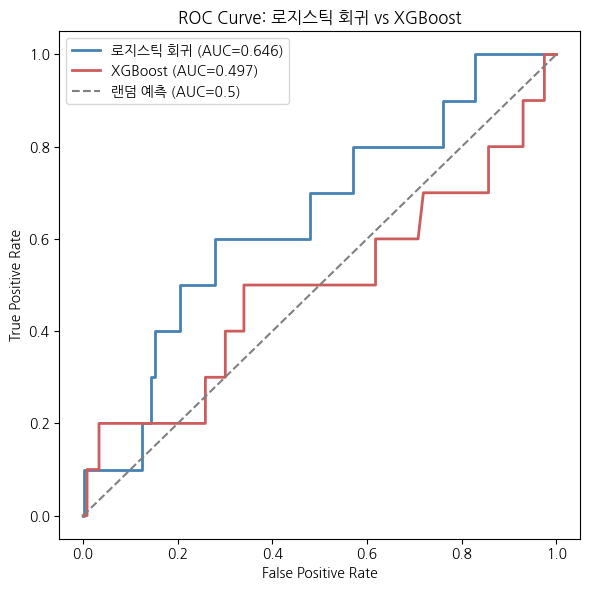

In [9]:
# ============================================================
# [Cell 4] PD 모델링: 로지스틱 회귀 vs XGBoost 비교
# ============================================================
!pip install --quiet xgboost

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from xgboost import XGBClassifier

# ------------------------------------------------------------
# 1) 모델링용 데이터 준비 (interest_coverage 제외, 결측 행 제거)
# ------------------------------------------------------------
features = ['debt_ratio', 'current_ratio', 'op_margin']
model_df = final_df.dropna(subset=features + ['default_label']).reset_index(drop=True)

X = model_df[features]
y = model_df['default_label']

print(f"모델링 표본 수: {len(model_df)}개 (부실: {y.sum()}개, 정상: {(y==0).sum()}개)")

# ------------------------------------------------------------
# 2) 학습/검증 분리 (stratify로 부실기업 비율을 양쪽에 동일하게 유지)
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"학습셋: {len(X_train)}개 (부실 {y_train.sum()}개) / 검증셋: {len(X_test)}개 (부실 {y_test.sum()}개)")

# ------------------------------------------------------------
# 3) 로지스틱 회귀 (표준화 + class_weight='balanced'로 소수 클래스 보정)
# ------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logit_model = LogisticRegression(class_weight='balanced', random_state=42)
logit_model.fit(X_train_scaled, y_train)
logit_pred_proba = logit_model.predict_proba(X_test_scaled)[:, 1]

# ------------------------------------------------------------
# 4) XGBoost (scale_pos_weight로 소수 클래스 가중치 부여)
# ------------------------------------------------------------
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# 5) 모델 성능 비교: ROC-AUC + KS statistic
# ------------------------------------------------------------
def calc_ks(y_true, y_proba):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    return np.max(tpr - fpr)  # KS = 정상/부실 분포 간 최대 누적분포 차이

auc_logit = roc_auc_score(y_test, logit_pred_proba)
auc_xgb = roc_auc_score(y_test, xgb_pred_proba)
ks_logit = calc_ks(y_test, logit_pred_proba)
ks_xgb = calc_ks(y_test, xgb_pred_proba)

print(f"\n=== 모델 성능 비교 (검증셋 기준) ===")
print(f"로지스틱 회귀 - ROC-AUC: {auc_logit:.3f}, KS: {ks_logit:.3f}")
print(f"XGBoost      - ROC-AUC: {auc_xgb:.3f}, KS: {ks_xgb:.3f}")

# ------------------------------------------------------------
# 6) 로지스틱 회귀 계수 해석 (표준화된 계수 = 상대적 영향력)
# ------------------------------------------------------------
coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': logit_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)
print(f"\n로지스틱 회귀 계수 (표준화 기준, 부호가 양수면 부실 위험 증가 방향):")
print(coef_df)

# ------------------------------------------------------------
# 7) 시각화: ROC 곡선 비교
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 6))
for name, proba, color in [('로지스틱 회귀', logit_pred_proba, 'steelblue'),
                             ('XGBoost', xgb_pred_proba, 'indianred')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', color=color, lw=2)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='랜덤 예측 (AUC=0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: 로지스틱 회귀 vs XGBoost')
ax.legend()
plt.tight_layout()

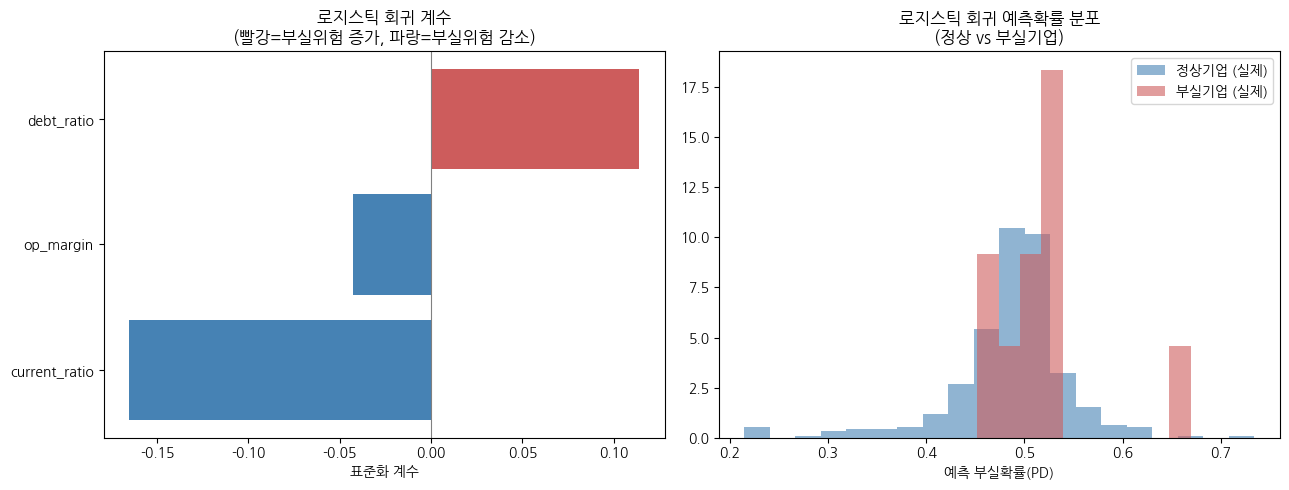

=== 최종 분석 요약 ===
표본: 코스닥 상장 SME(자산총계 5,000억 미만) 1220개
부실(감사의견 비적정) 비율: 2.79% (34개)
최종 모델: 로지스틱 회귀 (ROC-AUC 0.646, KS 0.322)
참고 비교 모델: XGBoost (ROC-AUC 0.497, KS 0.166) - 소표본 한계로 성능 저하

부실위험 증가 요인: 부채비율↑
부실위험 감소 요인: 유동비율↑, 영업이익률↑


In [10]:
# ============================================================
# [Cell 5] 최종 정리: 특성 중요도 시각화 + 예측확률 분포 확인
# ============================================================

# ------------------------------------------------------------
# 1) 로지스틱 회귀 계수 시각화 (표준화 계수 = 상대적 영향력)
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

coef_sorted = coef_df.sort_values('coefficient')
colors = ['indianred' if c > 0 else 'steelblue' for c in coef_sorted['coefficient']]
axes[0].barh(coef_sorted['feature'], coef_sorted['coefficient'], color=colors)
axes[0].axvline(0, color='gray', lw=0.8)
axes[0].set_title('로지스틱 회귀 계수\n(빨강=부실위험 증가, 파랑=부실위험 감소)')
axes[0].set_xlabel('표준화 계수')

# ------------------------------------------------------------
# 2) 정상기업 vs 부실기업의 예측확률 분포 비교
# ------------------------------------------------------------
# 모델이 부실기업에 실제로 더 높은 확률을 부여하는지 육안으로 확인하는 그래프
result_df = pd.DataFrame({'actual': y_test.values, 'pred_proba': logit_pred_proba})
axes[1].hist(result_df[result_df['actual']==0]['pred_proba'], bins=20, alpha=0.6,
             label='정상기업 (실제)', color='steelblue', density=True)
axes[1].hist(result_df[result_df['actual']==1]['pred_proba'], bins=10, alpha=0.6,
             label='부실기업 (실제)', color='indianred', density=True)
axes[1].set_title('로지스틱 회귀 예측확률 분포\n(정상 vs 부실기업)')
axes[1].set_xlabel('예측 부실확률(PD)')
axes[1].legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3) 최종 요약 출력 (README에 옮길 핵심 수치)
# ------------------------------------------------------------
print("=== 최종 분석 요약 ===")
print(f"표본: 코스닥 상장 SME(자산총계 5,000억 미만) {len(model_df)}개")
print(f"부실(감사의견 비적정) 비율: {y.mean()*100:.2f}% ({y.sum()}개)")
print(f"최종 모델: 로지스틱 회귀 (ROC-AUC {auc_logit:.3f}, KS {ks_logit:.3f})")
print(f"참고 비교 모델: XGBoost (ROC-AUC {auc_xgb:.3f}, KS {ks_xgb:.3f}) - 소표본 한계로 성능 저하")
print(f"\n부실위험 증가 요인: 부채비율↑")
print(f"부실위험 감소 요인: 유동비율↑, 영업이익률↑")